In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from sklearn.metrics import mean_absolute_error, mean_squared_error
from time import time
from copy import deepcopy
import seaborn as sns
sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 12))

https://www.statsmodels.org/dev/examples/notebooks/generated/mstl_decomposition.html

In [2]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 7)
Validation shape: (37550, 7)
Test shape: (37552, 55)


,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
DATETIME,,,,,,,
2010-07-02 12:00:00,11409.84,10035.63,9766.12,8038.00,11.0,637.616980,1.951466e+07
2010-07-02 12:30:00,11276.77,9686.17,9521.15,7809.31,11.5,706.576978,2.396405e+07
2010-07-02 13:00:00,11208.75,9513.42,9318.45,7483.69,11.6,784.498292,2.954100e+07
2010-07-02 13:30:00,11184.47,9255.59,9108.57,7117.23,11.8,862.789475,3.573147e+07
2010-07-02 14:00:00,11141.20,9019.79,8863.47,6812.03,12.0,927.314578,4.127579e+07


In [3]:
train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'

In [4]:
#train.info()

In [5]:
#train.describe()

In [6]:
#train[train['TEMPERATURE'] > 30]['TEMPERATURE'].describe()

In [7]:
# lookback_window = 17532
# subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window/2):]

# temp_subset_train = subset_train.copy()
# # group by hour
# temp_subset_train = temp_subset_train.resample('1h').mean()
# temp_subset_train.iloc[-720*4:].plot(y='TOTALDEMAND', title='Total Demand (last 17532 hours)', ylabel='MW')

In [8]:
# stl = MSTL(
#     subset_train['TOTALDEMAND'], 
#     windows=(11, 15, 19*4-1),
#     periods=(48, 336, 48*30),
#     iterate=3,
#     stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
# res = stl.fit()
# plt.figure(figsize=(16,12))
# fig = res.plot()
# plt.show()

In [9]:
# res.trend

In [10]:
# fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
# res.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
# ax[0].set_ylabel("seasonal_48")
# ax[0].set_title("Daily seasonality")

# res.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
# ax[1].set_ylabel("seasonal_336")
# ax[1].set_title("Weekly seasonality")

# res.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
# ax[2].set_ylabel("seasonal_1440")
# ax[2].set_title("Monthly seasonality")

# res.trend.iloc[: 48 * 365].plot(ax=ax[3])
# ax[3].set_ylabel("trend")
# ax[3].set_title("Trend")

# res.resid.iloc[: 48 * 365].plot(ax=ax[4])
# ax[4].set_ylabel("residuals")
# ax[4].set_title("Residuals")

# plt.tight_layout()

In [11]:
##acf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

In [12]:
#pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

https://otexts.com/fpp3/

The data is not stationary because of obvious seasonality trends. The ACF also supports this fact that it slowly decreases and increases again.

In [13]:
#plt.rc("figure", figsize=(10, 6))

In [14]:
# diff_48 = subset_train['TOTALDEMAND'].diff(48).dropna()
# stl_48 = MSTL(
#     diff_48, 
#     windows=(11, 15, 19*4-1),
#     periods=(48, 336, 48*30),
#     iterate=3,
#     stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
# res_48 = stl_48.fit()

In [15]:
# fig = res_48.plot()
# plt.show()
# diff_48.iloc[:lookback_window//2].plot(title='Seasonal Differencing (lag=48)')
# pacf_plot_diff_48 = plot_acf(diff_48, lags=min(48, len(diff_48)/2-1))

# fig, ax = plt.subplots(nrows=5)
# res_48.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
# ax[0].set_ylabel("seasonal_48")
# ax[0].set_title("Daily seasonality")

# res_48.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
# ax[1].set_ylabel("seasonal_336")
# ax[1].set_title("Weekly seasonality")

# res_48.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
# ax[2].set_ylabel("seasonal_1440")
# ax[2].set_title("Monthly seasonality")

# res_48.trend.iloc[: 48 * 365].plot(ax=ax[3])
# ax[3].set_ylabel("trend")
# ax[3].set_title("Trend")

# res_48.resid.iloc[: 48 * 365].plot(ax=ax[4])
# ax[4].set_ylabel("residuals")
# ax[4].set_title("Residuals")

# plt.tight_layout()

In [16]:
# # Create differenced series
# diff_1 = diff_48.diff().dropna()
# diff_1.iloc[:720].plot(title='First Order Differencing')
# stl_1 = MSTL(
#     diff_1, 
#     windows=(11, 15, 19*4-1),
#     periods=(48, 336, 48*30),
#     iterate=3,
#     stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
# res_1 = stl_1.fit()

In [17]:
# fig = res_1.plot()
# plt.show()
# diff_1.iloc[:lookback_window//2].plot(title='Seasonal Differencing (lag=48)')
# acf_plot_diff_1 = plot_acf(diff_1, lags=min(48, len(diff_1)/2-1))
# pacf_plot_diff_1 = plot_pacf(diff_1, lags=min(48, len(diff_1)/2-1))
# fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
# res_1.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
# ax[0].set_ylabel("seasonal_48")
# ax[0].set_title("Daily seasonality")

# res_1.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
# ax[1].set_ylabel("seasonal_336")
# ax[1].set_title("Weekly seasonality")

# res_1.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
# ax[2].set_ylabel("seasonal_1440")
# ax[2].set_title("Monthly seasonality")

# res_1.trend.iloc[: 48 * 365].plot(ax=ax[3])
# ax[3].set_ylabel("trend")
# ax[3].set_title("Trend")

# res_1.resid.iloc[: 48 * 365].plot(ax=ax[4])
# ax[4].set_ylabel("residuals")
# ax[4].set_title("Residuals")

# plt.tight_layout()

In [18]:
# plt.rc("figure", figsize=(10, 6))

In [ ]:
train['LOG_TOTALDEMAND'] = np.log(train['TOTALDEMAND'])
validation['LOG_TOTALDEMAND'] = np.log(validation['TOTALDEMAND'])
test['LOG_TOTALDEMAND'] = np.log(test['TOTALDEMAND'])

train['TEMP_SQUARED'] = train['TEMPERATURE'] ** 2
train['IS_WEEKEND'] = (train.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
train['IS_HEAT_WAVE'] = ((train['TEMPERATURE'] > 33)).astype(int)
validation['TEMP_SQUARED'] = validation['TEMPERATURE'] ** 2
validation['IS_WEEKEND'] = (validation.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
validation['IS_HEAT_WAVE'] = ((validation['TEMPERATURE'] > 33)).astype(int)
test['TEMP_SQUARED'] = test['TEMPERATURE'] ** 2
test['IS_WEEKEND'] = (test.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
test['IS_HEAT_WAVE'] = ((test['TEMPERATURE'] > 33)).astype(int)

In [ ]:
lookback_window = 1440 # 30 days of 30-minute data
subset_train = train[-lookback_window:].copy()

exog = ['demand_1_week_ago', 'demand_1_year_ago', 'TEMPERATURE','TEMP_SQUARED', 'IS_WEEKEND', 'IS_HEAT_WAVE']

In [ ]:
def sarimax_validation(model_fit:SARIMAXResults, validation_df:pd.DataFrame, target_var:str, exog_vars:list[str] | None, horizon:int, iters:int, is_target_log_transform=False):
    validation_target_df = validation_df.copy()
    exog_vars_df = validation_df[exog_vars] if exog_vars else None
    validation_target_df = validation_target_df[target_var]
    assert len(validation_target_df) >= horizon, "Validation target must be at least as long as the forecast horizon"
    assert exog_vars_df is None or len(exog_vars_df) >= horizon, "Exogenous variables must be at least as long as the forecast horizon"
    step_size = len(validation_target_df) // iters
    origins = range(0, len(validation_target_df) - horizon, step_size)
    print(f"\tRolling forecast origins: {len(list(origins))}")

    all_actuals = []
    all_predictions = []
    all_timestamps = []

    # Start our 'rolling' state with the base model trained on subset_train
    rolling_state = deepcopy(model_fit)

    for i in origins:
        # 1. First, make the forecast from the current state
        future_exog = exog_vars_df.iloc[i : i + horizon] if exog_vars_df is not None else None
        forecast = rolling_state.forecast(steps=horizon, exog=future_exog)
        if is_target_log_transform:
            forecast = np.exp(forecast)
        # Store predictions and actuals
        all_predictions.extend(forecast.values)
        actuals = validation_target_df.iloc[i : i + horizon].values
        if is_target_log_transform:
            actuals = np.exp(actuals)
        all_actuals.extend(actuals)
        all_timestamps.extend(validation_target_df.index[i : i + horizon].tolist())
        
        if (i // step_size) % 100 == 0 and i > 0:
            mae_so_far  = mean_absolute_error(all_actuals, all_predictions)
            mse_so_far  = mean_squared_error(all_actuals, all_predictions)
            rmse_so_far = np.sqrt(mse_so_far)
            print(f"\t\tOrigin {i//step_size} out of {len(origins)}: MAE so far: {mae_so_far:.2f} MW | MSE so far: {mse_so_far:.2f} MW^2 | RMSE so far: {rmse_so_far:.2f} MW")

        # 2. Then, advance the Origin forward by 'step_size'
        # We do this by APPENDING the model state with the actuals that occurred during that step
        new_endog = validation_target_df.iloc[i : i + step_size]
        new_exog = exog_vars_df.iloc[i : i + step_size] if exog_vars_df is not None else None
        
        # .extend() updates the internal Kalman filter state efficiently
        rolling_state = rolling_state.extend(new_endog, exog=new_exog)

    all_actuals = np.array(all_actuals)
    all_predictions = np.array(all_predictions)

    mae  = mean_absolute_error(all_actuals, all_predictions)
    mse  = mean_squared_error(all_actuals, all_predictions)
    rmse = np.sqrt(mse)
    print(f"Rolling Forecast (h={horizon} steps) — MAE: {mae:.2f} MW | MSE: {mse:.2f} MW^2 | RMSE: {rmse:.2f} MW")
    return all_timestamps, all_actuals, all_predictions, mae, rmse, mse


In [ ]:
def grid_search_sarimax(train_df:pd.DataFrame, validation_df:pd.DataFrame, target_var:str, exog_vars:list[str], val_horizon:int, val_iters:int, is_target_log_transform:bool,
                        p_values:list[int], d_values:list[int], q_values:list[int], p_s_values:list[int], d_s_values:list[int], q_s_values:list[int], period:int):
    best_training_aic = np.inf
    best_val_mse = np.inf
    best_order = None
    best_seasonal_order = None
    best_model = None
    progress_log = {
        'model_name': [],
        'training_aic': [],
        'validation_horizon': [],
        'validation_iters': [],
        'validation_mae': [],
        'validation_mse': [],
        'validation_rmse': [],
        'time_taken_seconds': []
    }
    for p in p_values:
        for d in d_values:
            for q in q_values:
                for p_s in p_s_values:
                    for d_s in d_s_values:
                        for q_s in q_s_values:
                                print(f"Fitting SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period})...")
                                start = time()
                                model = SARIMAX(
                                    train_df[target_var], 
                                    exog=train_df[exog_vars] if exog_vars else None,
                                    order=(p,d,q), 
                                    seasonal_order=(p_s,d_s,q_s,period)
                                )
                                model_fit = model.fit(disp=False)
                                end = time()
                                print(f"\tFitted SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}) - Training AIC: {model_fit.aic:.2f} | Time taken: {end - start:.2f} seconds\n")
                                try:
                                    print(f"\tValidating SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}) on horizon {val_horizon} with {val_iters} iterations...")
                                    _, _, _, mae, rmse, mse = sarimax_validation(model_fit, validation_df, target_var, exog_vars, horizon=val_horizon, iters=val_iters, is_target_log_transform=is_target_log_transform)
                                    if mse < best_val_mse:
                                        print(f"New best model found: SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}_h{val_horizon}) - MSE: {mse:.2f}")
                                        best_val_mse = mse
                                        best_order = (p,d,q)
                                        best_seasonal_order = (p_s,d_s,q_s,period)
                                        best_model = model_fit
                                        best_training_aic = model_fit.aic
                                        progress_log['model_name'].append(f"SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}_h{val_horizon})")
                                        progress_log['validation_horizon'].append(val_horizon)
                                        progress_log['validation_iters'].append(val_iters)
                                        progress_log['training_aic'].append(model_fit.aic)
                                        progress_log['validation_mae'].append(mae)
                                        progress_log['validation_rmse'].append(rmse)
                                        progress_log['validation_mse'].append(mse)
                                        progress_log['time_taken_seconds'].append(end - start)
                                except Exception as e:
                                    print(f"\tError validating SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}) on horizon {val_horizon} with {val_iters} iterations: {e}")
    
    print(f"Best SARIMAX{best_order}{best_seasonal_order} - AIC: {best_training_aic:.2f} | Validation MSE: {best_val_mse:.2f} | Validation RMSE: {np.sqrt(best_val_mse):.2f} | Time taken: {progress_log['time_taken_seconds'][-1]:.2f} seconds")
    return best_model, best_order, best_seasonal_order, progress_log

In [50]:
p = [4,3,2]
d = [0,1]
q = [0,1]
p_s = [1]
d_s = [1]
q_s = [1]
period = 48
best_model_h_48, best_order_h_48, best_seasonal_order_h_48, progress_log_h_48 = grid_search_sarimax(
    train_df=subset_train,
    validation_df=validation,
    target_var='LOG_TOTALDEMAND',
    exog_vars=exog,
    val_horizon=48,
    val_iters=1000,
    is_target_log_transform=True,
    p_values=p, d_values=d, q_values=q,
    p_s_values=p_s, d_s_values=d_s, q_s_values=q_s,
    period=period
)

Fitting SARIMAX(4,0,0)(1,1,1,48)...
	Fitted SARIMAX(4,0,0)(1,1,1,48) - Training AIC: -7852.25 | Time taken: 78.98 seconds

	Validating SARIMAX(4,0,0)(1,1,1,48) on horizon 48 with step size 48...
	Rolling forecast origins: 782
		Origin 100 out of 782: MAE so far: 599.21 MW | MSE so far: 744085.17 MW^2 | RMSE so far: 862.60 MW
		Origin 200 out of 782: MAE so far: 443.34 MW | MSE so far: 453523.81 MW^2 | RMSE so far: 673.44 MW
		Origin 300 out of 782: MAE so far: 401.79 MW | MSE so far: 363859.87 MW^2 | RMSE so far: 603.21 MW
		Origin 400 out of 782: MAE so far: 392.31 MW | MSE so far: 355198.62 MW^2 | RMSE so far: 595.99 MW
		Origin 500 out of 782: MAE so far: 396.89 MW | MSE so far: 354112.13 MW^2 | RMSE so far: 595.07 MW
		Origin 600 out of 782: MAE so far: 379.74 MW | MSE so far: 322015.63 MW^2 | RMSE so far: 567.46 MW
		Origin 700 out of 782: MAE so far: 368.88 MW | MSE so far: 300519.96 MW^2 | RMSE so far: 548.20 MW
Rolling Forecast (h=48 steps) — MAE: 372.48 MW | MSE: 304948.85 MW^

c:\Users\USER\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


	Fitted SARIMAX(3,0,0)(1,1,1,48) - Training AIC: -8405.46 | Time taken: 137.93 seconds

	Validating SARIMAX(3,0,0)(1,1,1,48) on horizon 48 with step size 48...
	Rolling forecast origins: 782
		Origin 100 out of 782: MAE so far: 628.98 MW | MSE so far: 816803.59 MW^2 | RMSE so far: 903.77 MW
		Origin 200 out of 782: MAE so far: 486.05 MW | MSE so far: 522789.66 MW^2 | RMSE so far: 723.04 MW
		Origin 300 out of 782: MAE so far: 455.88 MW | MSE so far: 443319.23 MW^2 | RMSE so far: 665.82 MW
		Origin 400 out of 782: MAE so far: 437.67 MW | MSE so far: 417637.84 MW^2 | RMSE so far: 646.25 MW
		Origin 500 out of 782: MAE so far: 431.14 MW | MSE so far: 403665.69 MW^2 | RMSE so far: 635.35 MW
		Origin 600 out of 782: MAE so far: 415.84 MW | MSE so far: 371970.69 MW^2 | RMSE so far: 609.89 MW
		Origin 700 out of 782: MAE so far: 410.96 MW | MSE so far: 358706.34 MW^2 | RMSE so far: 598.92 MW
Rolling Forecast (h=48 steps) — MAE: 411.51 MW | MSE: 361710.01 MW^2 | RMSE: 601.42 MW
Fitting SARIMAX

c:\Users\USER\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


	Fitted SARIMAX(3,0,1)(1,1,1,48) - Training AIC: -7761.47 | Time taken: 107.63 seconds

	Validating SARIMAX(3,0,1)(1,1,1,48) on horizon 48 with step size 48...
	Rolling forecast origins: 782
		Origin 100 out of 782: MAE so far: 599.01 MW | MSE so far: 736562.95 MW^2 | RMSE so far: 858.23 MW
		Origin 200 out of 782: MAE so far: 442.61 MW | MSE so far: 449145.30 MW^2 | RMSE so far: 670.18 MW
		Origin 300 out of 782: MAE so far: 399.98 MW | MSE so far: 359614.40 MW^2 | RMSE so far: 599.68 MW
		Origin 400 out of 782: MAE so far: 390.82 MW | MSE so far: 350809.63 MW^2 | RMSE so far: 592.29 MW
		Origin 500 out of 782: MAE so far: 396.00 MW | MSE so far: 350698.51 MW^2 | RMSE so far: 592.20 MW
		Origin 600 out of 782: MAE so far: 378.51 MW | MSE so far: 318535.23 MW^2 | RMSE so far: 564.39 MW
		Origin 700 out of 782: MAE so far: 367.49 MW | MSE so far: 297153.45 MW^2 | RMSE so far: 545.12 MW
Rolling Forecast (h=48 steps) — MAE: 371.12 MW | MSE: 301589.55 MW^2 | RMSE: 549.17 MW
New best model 

c:\Users\USER\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


	Fitted SARIMAX(2,1,0)(1,1,1,48) - Training AIC: -9030.83 | Time taken: 98.09 seconds

	Validating SARIMAX(2,1,0)(1,1,1,48) on horizon 48 with step size 48...
	Rolling forecast origins: 782
		Origin 100 out of 782: MAE so far: 591.37 MW | MSE so far: 784061.13 MW^2 | RMSE so far: 885.47 MW
		Origin 200 out of 782: MAE so far: 459.70 MW | MSE so far: 508147.67 MW^2 | RMSE so far: 712.84 MW
		Origin 300 out of 782: MAE so far: 432.23 MW | MSE so far: 426521.28 MW^2 | RMSE so far: 653.09 MW
		Origin 400 out of 782: MAE so far: 424.95 MW | MSE so far: 405369.94 MW^2 | RMSE so far: 636.69 MW
		Origin 500 out of 782: MAE so far: 428.67 MW | MSE so far: 398928.04 MW^2 | RMSE so far: 631.61 MW
		Origin 600 out of 782: MAE so far: 414.61 MW | MSE so far: 370228.32 MW^2 | RMSE so far: 608.46 MW
		Origin 700 out of 782: MAE so far: 405.65 MW | MSE so far: 352402.90 MW^2 | RMSE so far: 593.64 MW
Rolling Forecast (h=48 steps) — MAE: 410.74 MW | MSE: 358677.51 MW^2 | RMSE: 598.90 MW
Fitting SARIMAX(

In [ ]:
# p = 4
# d = 0
# q = 0
# p_s = 1
# d_s = 1
# q_s = 1
# period = 48

# model_sarima = SARIMAX(
#     subset_train['LOG_TOTALDEMAND'], 
#     exog=subset_train[exog],
#     order=(p,d,q), 
#     seasonal_order=(p_s,d_s,q_s,period)
#     )
# start = time()
# model_fit_sarima = model_sarima.fit()
# end = time()
# print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Model fitting took {end - start:.2f} seconds")
# print(model_fit_sarima.summary())

In [ ]:
# model_fit_sarima.resid.plot(title=f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Training Set')
# resid_acf_plot = plot_acf(model_fit_sarima.resid, lags=(len(model_fit_sarima.resid)-1)//4)
# resid_pacf_plot = plot_pacf(model_fit_sarima.resid, lags=(len(model_fit_sarima.resid)-1)//4)

2016-12-04 09:30:00 2016-12-19 09:00:00


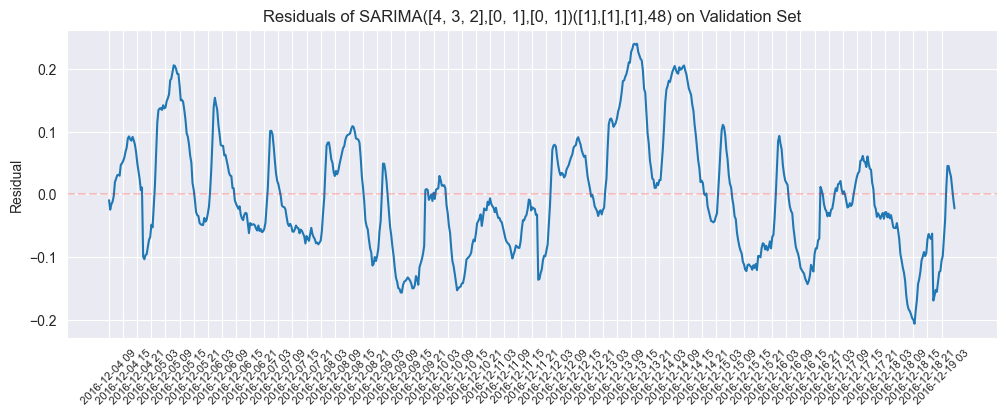

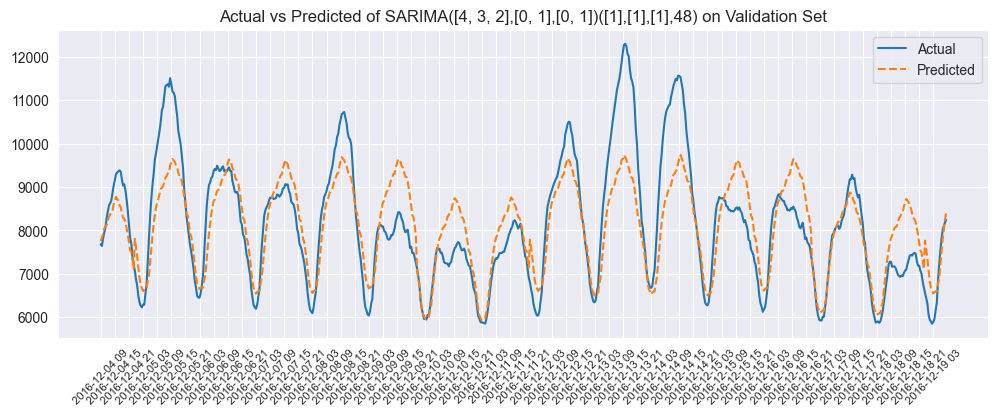

In [52]:
from datetime import datetime, timedelta

forecast_horizon = 720  
step_size = 48         
validation_sub = validation.copy()
validation_sub = validation_sub.iloc[:forecast_horizon]  # take only the first 720 rows for this test
print(validation_sub.index.min(), validation_sub.index.max())
predictions = best_model_h_48.forecast(
    steps=len(validation_sub), 
    exog=validation_sub[exog]
)
residuals = validation_sub['LOG_TOTALDEMAND'] - predictions

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_sub.index[0], validation_sub.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(validation_sub['TOTALDEMAND'], label='Actual')
plt.plot(np.exp(predictions), label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_sub.index[0], validation_sub.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.legend()
plt.show()

In [ ]:

from datetime import timedelta

forecast_horizon = 720  
step_size = 48         
validation = validation
validation['LOG_TOTALDEMAND'] = np.log(validation['TOTALDEMAND'])
validation['TEMP_SQUARED'] = validation['TEMPERATURE'] ** 2
validation['IS_WEEKEND'] = (validation.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
validation['IS_HEAT_WAVE'] = ((validation['TEMPERATURE'] > 33)).astype(int)

origins = range(0, len(validation) - forecast_horizon, step_size)
print(f"Rolling forecast origins: {len(list(origins))}")

all_actuals = []
all_predictions = []
all_timestamps = []

# Start our 'rolling' state with the base model trained on subset_train
rolling_state = model_fit_sarima

for i in origins:
    # 1. First, make the forecast from the current state
    future_exog = validation[exog].iloc[i : i + forecast_horizon]
    forecast = rolling_state.forecast(steps=forecast_horizon, exog=future_exog)
    
    # Store predictions and actuals
    all_predictions.extend(np.exp(forecast.values))
    all_actuals.extend(validation['TOTALDEMAND'].iloc[i : i + forecast_horizon].values)
    all_timestamps.extend(validation.index[i : i + forecast_horizon].tolist())
    
    if (i // step_size) % 10 == 0 and i > 0:
        mae_so_far  = mean_absolute_error(all_actuals, all_predictions)
        rmse_so_far = np.sqrt(mean_squared_error(all_actuals, all_predictions))
        mape_so_far = np.mean(np.abs((np.array(all_actuals) - np.array(all_predictions)) / np.array(all_actuals))) * 100
        print(f"Origin {i//step_size}: MAE so far: {mae_so_far:.2f} MW | RMSE so far: {rmse_so_far:.2f} MW | MAPE so far: {mape_so_far:.2f}%")

    # 2. Then, advance the Origin forward by 'step_size'
    # We do this by APPENDING the model state with the actuals that occurred during that step
    new_endog = validation['LOG_TOTALDEMAND'].iloc[i : i + step_size]
    new_exog = validation[exog].iloc[i : i + step_size]
    
    # .extend() updates the internal Kalman filter state efficiently
    rolling_state = rolling_state.extend(new_endog, exog=new_exog)

all_actuals = np.array(all_actuals)
all_predictions = np.array(all_predictions)

mae  = mean_absolute_error(all_actuals, all_predictions)
rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
mape = np.mean(np.abs((all_actuals - all_predictions) / all_actuals)) * 100
print(f"Rolling Forecast (h={forecast_horizon} steps) — MAE: {mae:.2f} MW | RMSE: {rmse:.2f} MW | MAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(14, 4))
plt.plot(all_timestamps, all_actuals, label='Actual')
plt.plot(all_timestamps, all_predictions, label='Predicted', linestyle='--', alpha=0.8)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(rotation=45, fontsize=8)
plt.title(f'Rolling Forecast from Origin — SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}), h={forecast_horizon}')
plt.legend()
plt.tight_layout()
plt.show()

Rolling forecast origins: 768
Origin 10: MAE so far: 741.01 MW | RMSE so far: 1024.00 MW | MAPE so far: 9.01%
Origin 20: MAE so far: 686.85 MW | RMSE so far: 945.96 MW | MAPE so far: 8.46%
Origin 30: MAE so far: 761.65 MW | RMSE so far: 1039.89 MW | MAPE so far: 9.16%
Origin 40: MAE so far: 840.17 MW | RMSE so far: 1164.40 MW | MAPE so far: 9.68%
Origin 50: MAE so far: 896.52 MW | RMSE so far: 1240.13 MW | MAPE so far: 10.21%
Origin 60: MAE so far: 956.28 MW | RMSE so far: 1316.86 MW | MAPE so far: 10.66%
Origin 70: MAE so far: 1035.05 MW | RMSE so far: 1426.04 MW | MAPE so far: 11.61%
Origin 80: MAE so far: 982.07 MW | RMSE so far: 1367.48 MW | MAPE so far: 11.10%
Origin 90: MAE so far: 918.20 MW | RMSE so far: 1302.62 MW | MAPE so far: 10.44%
Origin 100: MAE so far: 869.16 MW | RMSE so far: 1249.10 MW | MAPE so far: 9.92%
Origin 110: MAE so far: 836.28 MW | RMSE so far: 1208.33 MW | MAPE so far: 9.59%
Origin 120: MAE so far: 813.34 MW | RMSE so far: 1176.55 MW | MAPE so far: 9.42%
Or

KeyboardInterrupt: 

In [ ]:
all_predictions.shape

In [ ]:
# import pmdarima as pm

# # Auto-fit the SARIMA model
# # Note: Since your data is 30-min intervals, your seasonal period (m) is 48 for daily seasonality.
# auto_model = pm.auto_arima(
#     y=subset_train['TOTALDEMAND'],
#     X=subset_train[exog],
#     start_p=4, start_q=0,
#     max_p=5, max_q=3,
#     m=48,              # Seasonal period (48 for daily seasonality with 30-min data)
#     start_P=1, start_Q=0,
#     max_P=7, max_Q=2,
#     d=None,            # Let the model determine 'd'
#     D=None,            # Let the model determine 'D'
#     seasonal=True,     # Enable SARIMA
#     trace=True,        # Print the search progress
#     error_action='ignore',  
#     suppress_warnings=True, 
#     stepwise=True,      # False for full grid search (rather than stepwise algorithm)
#     num_workers=-1,
#     max_order = 7
# )

In [ ]:
# from datetime import datetime, timedelta

# print(validation_target.index.min(), validation_target.index.max())
# predictions = auto_model.predict(
#     n_periods=len(validation_target),
#     X=validation_target[exog]
# )
# residuals = validation_target['TOTALDEMAND'] - predictions

# plt.figure(figsize=(12,4))
# plt.plot(residuals)
# plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
# plt.ylabel('Residual')
# # for xticks, show as format 'YYYY-MM-DD HH'
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
# plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
# plt.axhline(0, color='red', linestyle='--', alpha=0.2)
# plt.show()

# plt.figure(figsize=(12,4))
# plt.plot(validation_target['TOTALDEMAND'], label='Actual')
# plt.plot(predictions, label='Predicted', linestyle='--')
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
# plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
# plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
# plt.legend()
# plt.show()

Key notes:
* SARIMAX's AR and MA portion require actualized data to advance their "states" in order to predict the next timesteps.
* This is different from refitting and updating its parameters.
* This basically means, since ARIMA uses lag operators of BOTH the endogenous and exogenous, whenever it makes a forecast, it has to use actualized data to update those lags. Otherwise, it's predictions is based on a "disjointed" version of events.

For example, training data is up to 2017-01-01. If we force it to make predictions on 2018-01-01, it will rely on lag AR data it stored in its state to predict this. Meaning if it uses AR(2), then it will use 2016-12-31 and 2016-12-30 to predict 2018-01-01 events, which is incorrect.